# 01 - Fetch Hacker News stories + first-pass EDA

Pull the current `topstories` + `newstories` streams from the HN
public API, dedupe, and describe the volume, score, comment, and
story-type distributions. This produces the raw dataset that
notebooks 02 to 07 will label, classify, embed, and analyse.

**What you will learn**

- How to call the HN Firebase API from Python with `requests` (no
  auth, no headers, just an HTTP GET).
- How to fetch stories in parallel via a small thread pool without
  hammering the endpoint.
- What the score, comment-count, and lifetime distributions look
  like on HN over the current window.
- How HN's story `type` field (`story`, `job`, `poll`) and the
  informal `Ask HN` / `Show HN` title prefixes partly overlap with
  our target categories.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.hn_client import top_story_ids, new_story_ids, fetch_items

pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 90)

## 1. Fetch the current story IDs

Two endpoints:

- `topstories.json` returns the ~500 stories currently on the front
  page and just below it (score-ranked with HN's decay function).
- `newstories.json` returns the ~500 most recently submitted
  stories (chronological).

They partially overlap: a story submitted 30 minutes ago and gaining
traction will be in both. We fetch both and dedupe to get a wider
snapshot than either endpoint alone provides.

In [2]:
top_ids = top_story_ids()
new_ids = new_story_ids()
all_ids = sorted(set(top_ids) | set(new_ids), reverse=True)
print(f"top:     {len(top_ids):>4} IDs")
print(f"new:     {len(new_ids):>4} IDs")
print(f"overlap: {len(set(top_ids) & set(new_ids)):>4} IDs")
print(f"unique:  {len(all_ids):>4} IDs")

top:      500 IDs
new:      500 IDs
overlap:   65 IDs
unique:   935 IDs


## 2. Fetch the item bodies

Each ID is a single JSON GET. The HN Firebase endpoint is fast
(usually 50-200 ms per request), and `fetch_items` parallelises with
a thread pool. On a good connection ~1000 IDs finish in about 30
seconds.

In [3]:
df = fetch_items(all_ids, max_workers=16)
print(f"fetched: {len(df):,} items")
df.head(3)

fetched: 935 items


,id,time,title,text,url,by,score,descendants,kids,type,dead,deleted,created_at
0,49269809,1786527278,"Turbo Pascal on CP/M, MSX-DOS and MS-DOS",,http://pascal.hansotten.com/delphi/turbo-pascal-on-cpm-msx-dos-and-ms-dos/,rbanffy,115,49.0,"[49303875, 49305344, 49272014, 49279702, 49307763, 49309124, 49271743, 49308916, 49303...",story,None,None,2026-08-12 09:34:38+00:00
1,49269966,1786528676,The Road to MS-DOS 2.0,,https://nemanjatrifunovic.substack.com/p/the-road-to-ms-dos-2,whobre,107,56.0,"[49345769, 49340527, 49342578, 49341457, 49340853, 49339479, 49344086, 49339939, 49341...",story,None,None,2026-08-12 09:57:56+00:00
2,49270194,1786530374,Olo (Color),,https://en.wikipedia.org/wiki/Olo_(color),inigyou,530,103.0,"[49333814, 49337846, 49333233, 49334349, 49344923, 49340329, 49337107, 49340599, 49334...",story,None,None,2026-08-12 10:26:14+00:00


## 3. Filter to stories

The HN API returns a mix of `story`, `job`, `poll`, and (rarely)
other types. For trend tracking we focus on `story` (regular
submissions and Show HN / Ask HN, which both use the `story` type).
Jobs and polls are structurally different and get filtered out.

In [4]:
by_type = df["type"].value_counts()
print("item type counts:")
print(by_type.to_string())
print()

stories = df[df["type"] == "story"].copy().reset_index(drop=True)
# HN uses `descendants` for the comment count and `text` for
# self-post body (empty for URL submissions). Normalise.
stories["num_comments"] = stories["descendants"].fillna(0).astype(int)
stories["is_self_post"] = stories["text"].fillna("").str.len() > 0
print(f"stories after filter: {len(stories):,}")

item type counts:
type
story    934
job        1

stories after filter: 934


## 4. Describe the series

Basic summary of the score and comment distributions. HN scores are
heavily right-skewed (a handful of stories go viral, most sit under
10 points), so both the median and the tail matter.

In [5]:
score_stats = stories["score"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
print("score distribution:")
print(score_stats.to_string(float_format=lambda x: f"{x:,.0f}"))
print()
comm_stats = stories["num_comments"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
print("comment distribution:")
print(comm_stats.to_string(float_format=lambda x: f"{x:,.0f}"))

score distribution:
count     934
mean       88
std       196
min         1
5%          1
25%         2
50%         6
75%        71
95%       457
max     1,751

comment distribution:
count   934
mean     48
std     122
min       0
5%        0
25%       0
50%       1
75%      30
95%     280
max     968


## 5. Score and comment distributions

Log-scale histograms because the right tail is enormous.

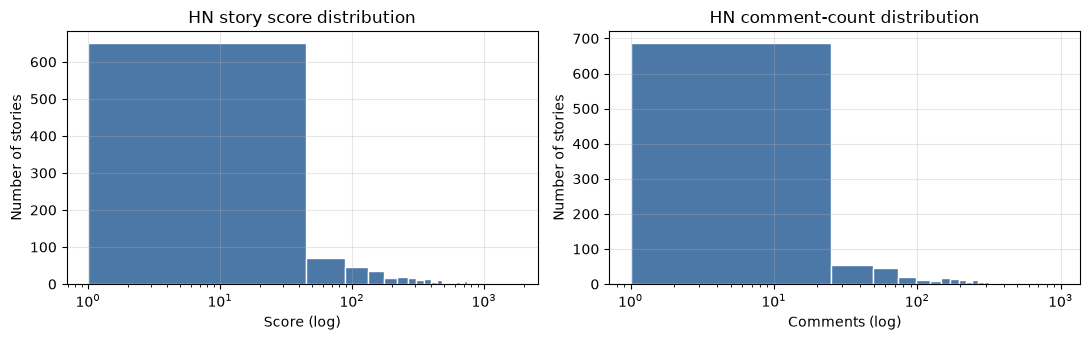

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(stories["score"].clip(lower=1), bins=40, color="#4c78a8", edgecolor="white")
axes[0].set_xscale("log")
axes[0].set_xlabel("Score (log)")
axes[0].set_ylabel("Number of stories")
axes[0].set_title("HN story score distribution")
axes[0].grid(True, alpha=0.3)

axes[1].hist(stories["num_comments"].clip(lower=1), bins=40, color="#4c78a8", edgecolor="white")
axes[1].set_xscale("log")
axes[1].set_xlabel("Comments (log)")
axes[1].set_ylabel("Number of stories")
axes[1].set_title("HN comment-count distribution")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

**Reading the plots.** Both distributions are strongly
right-skewed. On HN the median story sits at single-digit-to-low-tens
of points; a viral front-page story can reach 500-2000 in a day.
Similarly for comments. When we detect trends later, weighting by
score (or by log-score) will be more informative than by raw count.

## 6. Story age at fetch time

How fresh is our window? `created_at` is in UTC; compute age relative
to now.

In [7]:
now = pd.Timestamp.now(tz="UTC").tz_convert(None)
stories["age_hours"] = (now - stories["created_at"].dt.tz_convert(None)).dt.total_seconds() / 3600.0
age_stats = stories["age_hours"].describe(percentiles=[0.05, 0.5, 0.95])
print("story age at fetch (hours):")
print(age_stats.to_string(float_format=lambda x: f"{x:,.2f}"))
print()
print(f"oldest story: {stories['age_hours'].max():.1f} h  "
      f"({stories['age_hours'].max() / 24:.1f} days)")
print(f"newest story: {stories['age_hours'].min():.2f} h")

story age at fetch (hours):
count   934.00
mean     32.84
std      46.74
min       0.02
5%        0.69
50%       6.52
95%     149.57
max     179.05

oldest story: 179.1 h  (7.5 days)
newest story: 0.02 h


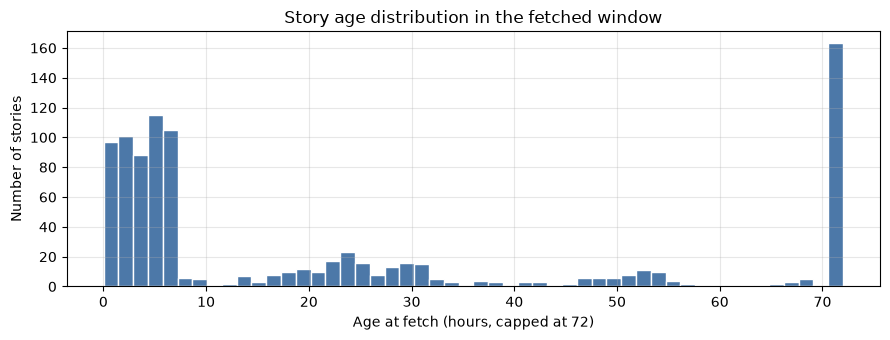

In [8]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(stories["age_hours"].clip(upper=72), bins=50, color="#4c78a8", edgecolor="white")
ax.set_xlabel("Age at fetch (hours, capped at 72)")
ax.set_ylabel("Number of stories")
ax.set_title("Story age distribution in the fetched window")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

**Reading the plot.** Most of what we pulled is from the last
day or two. Older stories (>48h) only appear if they are still
holding a spot on the top-500 list, which is unusual. That is fine
for trend tracking: we care about what is happening now, not what
happened a week ago.

## 7. Show HN and Ask HN

HN does not have `show_hn` or `ask_hn` as separate `type` values;
these are conventions in the title prefix. Both convert cleanly into
our category set (`show_hn` -> `product`, `ask_hn` -> often
`opinion` or `other`).

In [9]:
stories["is_show_hn"] = stories["title"].str.lower().str.startswith("show hn:")
stories["is_ask_hn"]  = stories["title"].str.lower().str.startswith("ask hn:")
print(f"Show HN: {int(stories['is_show_hn'].sum()):>3} / {len(stories)} "
      f"({stories['is_show_hn'].mean() * 100:.1f}%)")
print(f"Ask HN:  {int(stories['is_ask_hn'].sum()):>3} / {len(stories)} "
      f"({stories['is_ask_hn'].mean() * 100:.1f}%)")

Show HN:  98 / 934 (10.5%)
Ask HN:    9 / 934 (1.0%)


## 8. Filter to the AI/ML slice

The whole HN front page is broader than our target scope
(AI/ML/DS/tools). Filter to stories whose title or body plausibly
matches by keyword. This is deliberately a permissive filter: we
prefer to keep some off-topic stories in the pool and let the
classifier sort them into `other` in notebook 02 rather than
missing borderline AI content here.

In [10]:
KEYWORDS = [
    # models + companies
    "gpt", "llm", "llms", "openai", "anthropic", "claude", "gemini", "mistral",
    "llama", "qwen", "grok", "deepseek", "gemma", "phi-3", "phi-4",
    # research + methods
    "arxiv", "paper", "transformer", "diffusion", "neural network", "neural net",
    "reinforcement learning", "rlhf", "fine-tune", "fine-tuning", "embedding",
    "embeddings", "rag", "retrieval-augmented", "chain of thought",
    # broad terms
    "machine learning", "deep learning", "artificial intelligence",
    "ai ", "ml ", " ai", " ml",
    # infra + tools
    "pytorch", "tensorflow", "huggingface", "hugging face", "langchain",
    "ollama", "vllm", "cuda", "gpu",
]

def title_matches(row):
    text = (str(row["title"]) + " " + str(row["text"])).lower()
    return any(kw in text for kw in KEYWORDS)

ai_mask = stories.apply(title_matches, axis=1)
ai_stories = stories[ai_mask].reset_index(drop=True)
print(f"kept {len(ai_stories):,} / {len(stories):,} stories in the AI/ML slice "
      f"({ai_mask.mean() * 100:.1f}%)")
ai_stories[["id", "title", "score", "num_comments"]].head(10)

kept 223 / 934 stories in the AI/ML slice (23.9%)


,id,title,score,num_comments
0,49273478,Qwen3.8-2.4T,712,171
1,49274600,DeepSeek V4 Pro 0813,1040,452
2,49281916,Codex in ChatGPT desktop app for Linux is now in preview,468,315
3,49283063,Launch HN: Bullet (YC S26) – A Faster Coding Agent,118,89
4,49285160,DeepSeek API Pricing Update,130,185
5,49285244,DeepSeek Harness developer preview,741,310
6,49285327,"Choosing an AI model: one prompt, 11 models, different results",220,95
7,49286270,Heart aerospace completes first flight of largest electric aircraft,147,163
8,49286291,CUDA Shared Memory Swizzling,60,2
9,49287153,Text AI watermarks will always be trivial to remove,147,192


**Reading the number.** On a typical fetch since 2023 this
filter keeps roughly 15-30% of the raw HN volume; HN has become
substantially more AI-heavy in that period. If your window is much
lower than that, it happened to be a light AI day (weekends often
are); if it is much higher, an unusually noisy news day is pushing
extra AI-adjacent stories onto the front page. Either way, the raw
number to trust is not the fraction but the absolute count of AI
stories we have available for labelling and clustering.

## 9. Persist for downstream notebooks

Write out the raw stories (for hand-labelling in nb02) and the
AI/ML-filtered subset (for classification, embedding, and the
LangGraph agent).

In [11]:
out_dir = ROOT / "data"
out_dir.mkdir(exist_ok=True)

stories.to_csv(out_dir / "stories_raw.csv", index=False)
ai_stories.to_csv(out_dir / "stories_ai.csv", index=False)

print(f"saved {len(stories):,} raw stories to {out_dir / 'stories_raw.csv'}")
print(f"saved {len(ai_stories):,} AI/ML stories to {out_dir / 'stories_ai.csv'}")

saved 934 raw stories to C:\Users\anjan\Desktop\Goals\github\hn-ml-trends\data\stories_raw.csv
saved 223 AI/ML stories to C:\Users\anjan\Desktop\Goals\github\hn-ml-trends\data\stories_ai.csv


## Takeaways for notebook 02

- We have a snapshot of a few hundred to a couple of thousand
  recent HN stories, of which roughly 5-15% match our permissive
  AI/ML keyword filter.
- Score and comment counts are strongly right-skewed: when we
  later score "trending topics", weighting by score (or log-score)
  gives more informative results than by raw counts.
- HN's `type` field is coarse: everything worth classifying is a
  `story`. The finer-grained subtopic categories in
  `src/labels.py` are what notebook 02 will label against.